# League-Wide Weather Trends Analysis

Loads `heatmap_data_all_stadiums.csv` (exported by `uniform_analysis.ipynb`) and `stadium_metadata.csv`,
then produces league-wide comparisons of weather effects on away-team performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

DATASETS_DIR = os.path.join('..', 'data')
GRAPHICS_DIR = 'league_trend_graphics'
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# --- Load data ---
heatmap = pd.read_csv(os.path.join(DATASETS_DIR, 'heatmap_data_all_stadiums.csv'))
metadata = pd.read_csv('stadium_metadata.csv')

# --- Merge on team_code ---
df = heatmap.merge(metadata[['team_code', 'roof_type', 'setting']], on='team_code', how='left')

# --- Create roof group: covered vs open_air ---
df['roof_group'] = df['roof_type'].map({
    'retractable': 'covered',
    'fixed_dome': 'covered',
    'open_air': 'open_air',
})

print(f"Loaded {len(df)} rows")
print(f"\nRoof group counts (unique stadiums):")
print(df.groupby('roof_group')['team_code'].nunique())
print(f"\nSetting counts among open-air stadiums:")
print(df[df['roof_group'] == 'open_air'].groupby('setting')['team_code'].nunique())

/Users/avabrown/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/avabrown/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


Loaded 3000 rows

Roof group counts (unique stadiums):
roof_group
covered      8
open_air    22
Name: team_code, dtype: int64

Setting counts among open-air stadiums:
setting
suburban     4
urban       18
Name: team_code, dtype: int64


## Analysis 3: Dome vs. Open Air Comparison

Compare the magnitude of weather effects between covered (retractable + fixed dome) and open-air stadiums.
Dome stadiums should theoretically show near-zero weather deviations (sanity check).

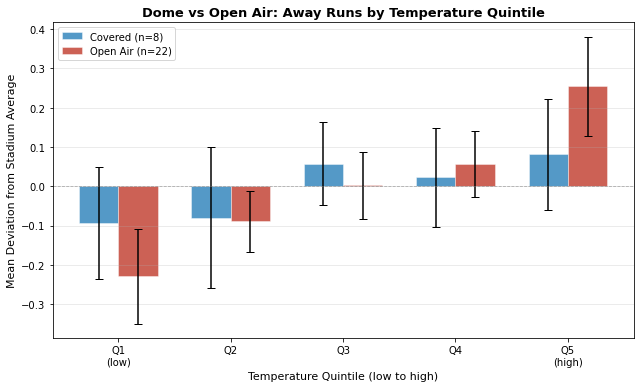

  Saved: dome_vs_open_temp_away_runs.png


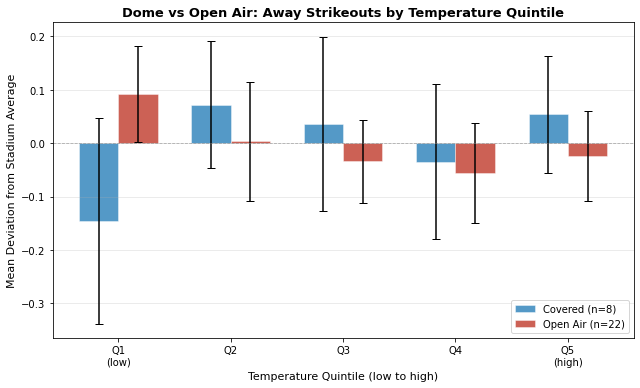

  Saved: dome_vs_open_temp_away_strikeouts.png


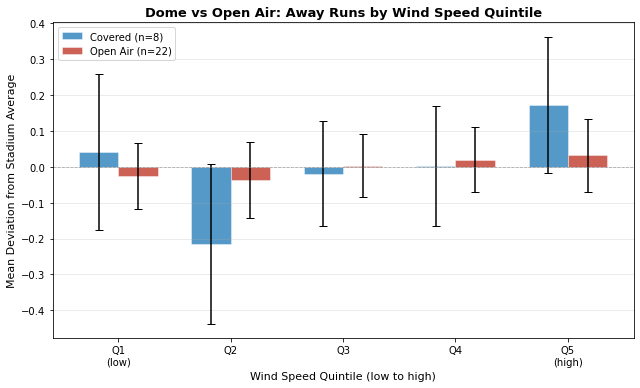

  Saved: dome_vs_open_wspd_away_runs.png


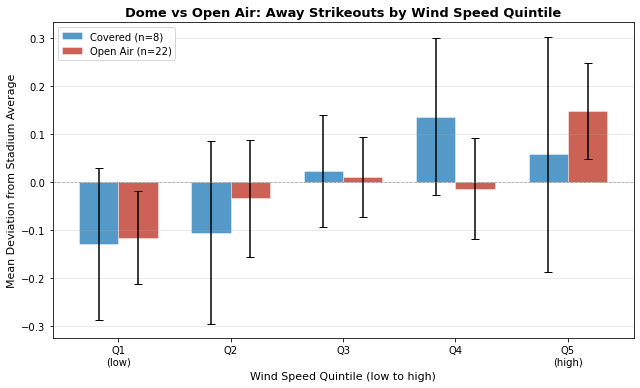

  Saved: dome_vs_open_wspd_away_strikeouts.png


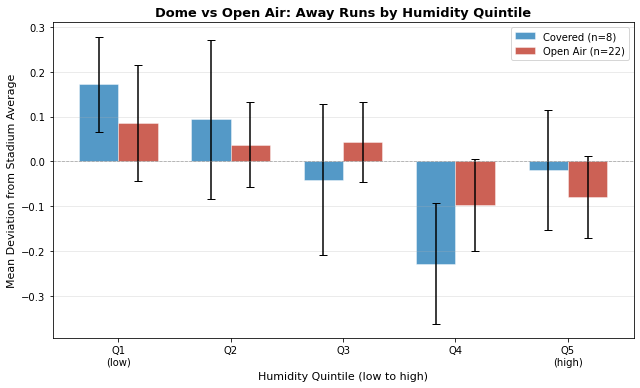

  Saved: dome_vs_open_rhum_away_runs.png


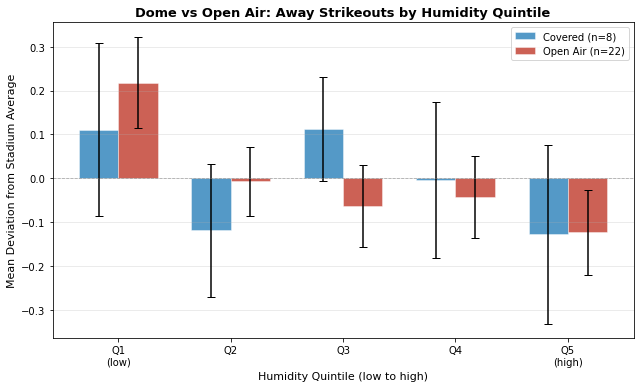

  Saved: dome_vs_open_rhum_away_strikeouts.png


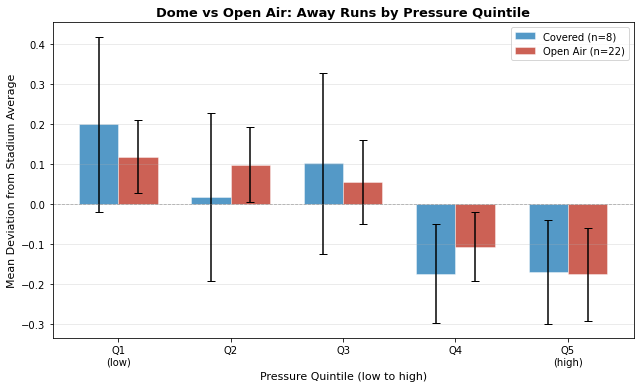

  Saved: dome_vs_open_pres_away_runs.png


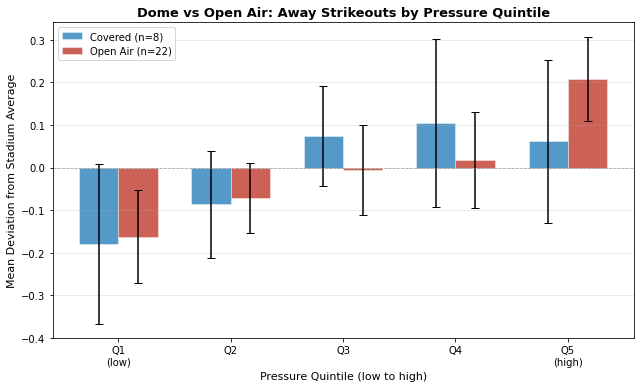

  Saved: dome_vs_open_pres_away_strikeouts.png

All 8 charts saved to league_trend_graphics/


In [2]:
WEATHER_LABELS = {
    'temp': 'Temperature',
    'wspd': 'Wind Speed',
    'rhum': 'Humidity',
    'pres': 'Pressure',
}

METRIC_LABELS = {
    'away_runs': 'Away Runs',
    'away_strikeouts': 'Away Strikeouts',
}

GROUP_COLORS = {
    'covered': '#2980b9',
    'open_air': '#c0392b',
}

bar_width = 0.35

for weather_var, weather_label in WEATHER_LABELS.items():
    for metric, metric_label in METRIC_LABELS.items():
        subset = df[(df['weather_variable'] == weather_var) & (df['metric'] == metric)].copy()

        # For each (roof_group, quintile_order), compute mean and SE across stadiums
        grouped = (
            subset
            .groupby(['roof_group', 'quintile_order'])['diff_from_mean']
            .agg(['mean', 'std', 'count'])
            .reset_index()
        )
        grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])

        fig, ax = plt.subplots(figsize=(9, 5.5))
        quintiles = sorted(grouped['quintile_order'].unique())
        x = np.arange(len(quintiles))

        for i, (group, color) in enumerate(GROUP_COLORS.items()):
            g = grouped[grouped['roof_group'] == group].set_index('quintile_order')
            means = [g.loc[q, 'mean'] if q in g.index else 0 for q in quintiles]
            ses = [g.loc[q, 'se'] if q in g.index else 0 for q in quintiles]
            n_stadiums = g['count'].iloc[0] if len(g) > 0 else 0
            offset = -bar_width / 2 + i * bar_width
            ax.bar(
                x + offset, means, bar_width,
                yerr=[1.96 * s for s in ses],
                label=f'{group.replace("_", " ").title()} (n={int(n_stadiums)})',
                color=color, alpha=0.8,
                capsize=4, edgecolor='white', linewidth=0.5,
            )

        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels([f'Q{q}\n(low)' if q == 1 else f'Q{q}\n(high)' if q == len(quintiles) else f'Q{q}' for q in quintiles])
        ax.set_xlabel(f'{weather_label} Quintile (low to high)', fontsize=11)
        ax.set_ylabel('Mean Deviation from Stadium Average', fontsize=11)
        ax.set_title(f'Dome vs Open Air: {metric_label} by {weather_label} Quintile',
                     fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()

        filename = f'dome_vs_open_{weather_var}_{metric}.png'
        fig.savefig(os.path.join(GRAPHICS_DIR, filename), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {filename}")

print(f"\nAll 8 charts saved to {GRAPHICS_DIR}/")

## Analysis 4: Urban vs. Suburban Comparison (Open-Air Only)

Compare weather effects between urban and suburban open-air stadiums.
Covered stadiums are excluded to isolate the weather signal.
Tests the urban heat island / wind shielding hypothesis.

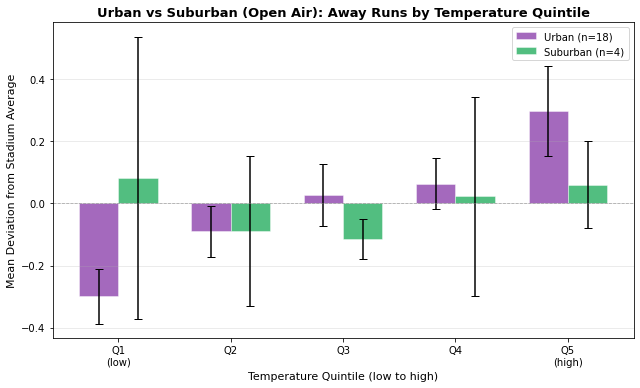

  Saved: urban_vs_suburban_temp_away_runs.png


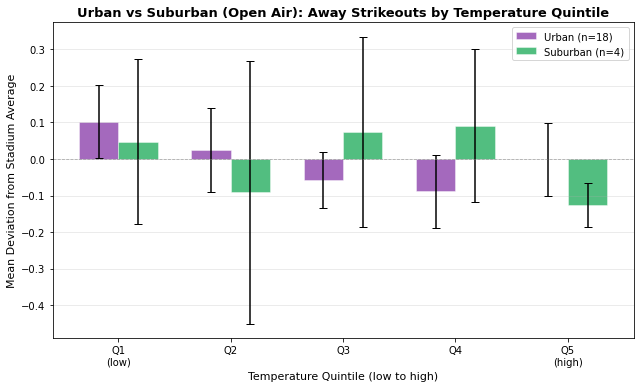

  Saved: urban_vs_suburban_temp_away_strikeouts.png


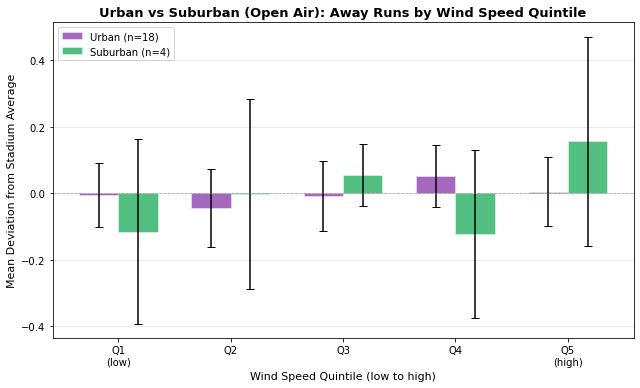

  Saved: urban_vs_suburban_wspd_away_runs.png


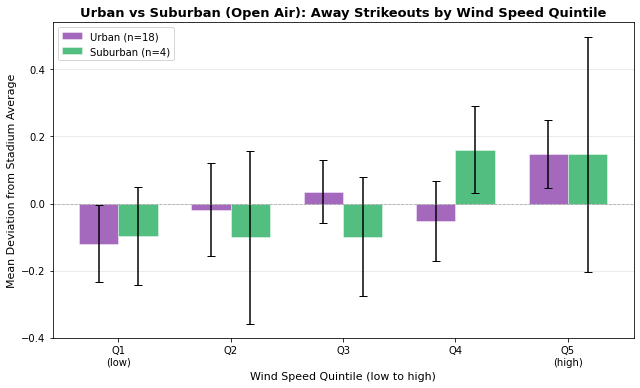

  Saved: urban_vs_suburban_wspd_away_strikeouts.png


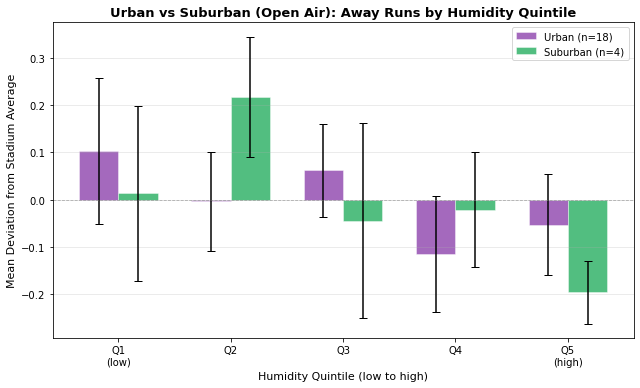

  Saved: urban_vs_suburban_rhum_away_runs.png


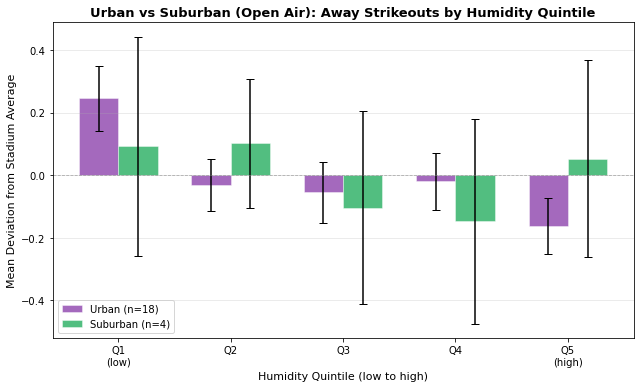

  Saved: urban_vs_suburban_rhum_away_strikeouts.png


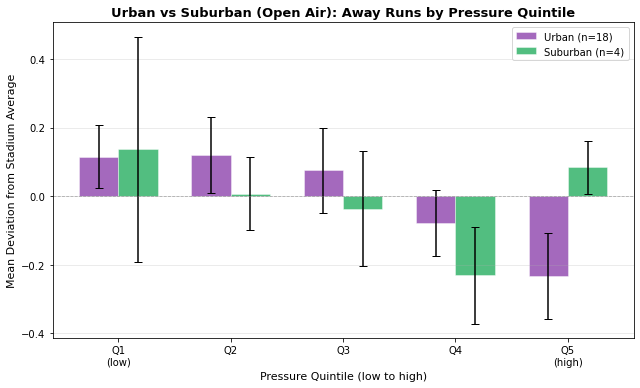

  Saved: urban_vs_suburban_pres_away_runs.png


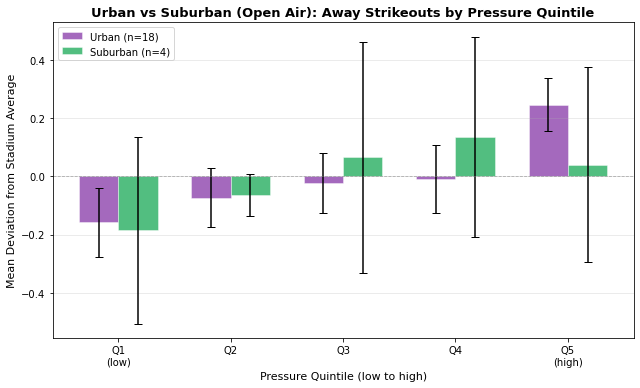

  Saved: urban_vs_suburban_pres_away_strikeouts.png

All 8 charts saved to league_trend_graphics/


In [3]:
SETTING_COLORS = {
    'urban': '#8e44ad',
    'suburban': '#27ae60',
}

# Filter to open-air stadiums only
df_open = df[df['roof_group'] == 'open_air'].copy()

bar_width = 0.35

for weather_var, weather_label in WEATHER_LABELS.items():
    for metric, metric_label in METRIC_LABELS.items():
        subset = df_open[(df_open['weather_variable'] == weather_var) & (df_open['metric'] == metric)]

        grouped = (
            subset
            .groupby(['setting', 'quintile_order'])['diff_from_mean']
            .agg(['mean', 'std', 'count'])
            .reset_index()
        )
        grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])

        fig, ax = plt.subplots(figsize=(9, 5.5))
        quintiles = sorted(grouped['quintile_order'].unique())
        x = np.arange(len(quintiles))

        for i, (setting, color) in enumerate(SETTING_COLORS.items()):
            g = grouped[grouped['setting'] == setting].set_index('quintile_order')
            means = [g.loc[q, 'mean'] if q in g.index else 0 for q in quintiles]
            ses = [g.loc[q, 'se'] if q in g.index else 0 for q in quintiles]
            n_stadiums = g['count'].iloc[0] if len(g) > 0 else 0
            offset = -bar_width / 2 + i * bar_width
            ax.bar(
                x + offset, means, bar_width,
                yerr=[1.96 * s for s in ses],
                label=f'{setting.title()} (n={int(n_stadiums)})',
                color=color, alpha=0.8,
                capsize=4, edgecolor='white', linewidth=0.5,
            )

        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels([f'Q{q}\n(low)' if q == 1 else f'Q{q}\n(high)' if q == len(quintiles) else f'Q{q}' for q in quintiles])
        ax.set_xlabel(f'{weather_label} Quintile (low to high)', fontsize=11)
        ax.set_ylabel('Mean Deviation from Stadium Average', fontsize=11)
        ax.set_title(f'Urban vs Suburban (Open Air): {metric_label} by {weather_label} Quintile',
                     fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()

        filename = f'urban_vs_suburban_{weather_var}_{metric}.png'
        fig.savefig(os.path.join(GRAPHICS_DIR, filename), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {filename}")

print(f"\nAll 8 charts saved to {GRAPHICS_DIR}/")